In [2]:
%pip install torch pandas matplotlib seaborn transformers datasets scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import gc

/home/ubuntu/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ---------------------------------------------------------
# 1. Prompt / Dataset Loading
# ---------------------------------------------------------
class DataLoader:
    """
    Handles fetching and preparing text data to feed into the models.
    Relies on the Hugging Face `datasets` library.
    """

    @staticmethod
    def load_sample_text(dataset_path="Salesforce/wikitext", name="wikitext-103-raw-v1", split="validation", min_length=50, num_paragraphs=5):
        """
        Loads a dataset from the Hugging Face Hub, filters out short/empty lines, 
        and joins several paragraphs together to create a single long input prompt.

        WHAT NEEDS TO BE CUSTOMIZED (For your own data):
        ------------------------------------------------
        If you don't want to use WikiText, you can easily swap in any text dataset from 
        Hugging Face (or your own local CSV/JSON) by changing these parameters:
        
        - `dataset_path` (str): The Hugging Face repo ID (e.g., "imdb", "allenai/c4", or "your-username/your-dataset").
        - `name` (str): The specific subset configuration of the dataset. If the dataset 
          doesn't have subsets, you can pass `name=None`.
        - `split` (str): Which split to use (usually "train", "test", or "validation").

        Other Parameters:
        - min_length (int): Ignores text snippets with fewer characters than this (removes noise/headers).
        - num_paragraphs (int): How many valid text rows to combine into your final prompt. 
          (Increase this if you want to test the model on a longer context window).

        Returns:
        - str: A single continuous string of text ready to be tokenized.

        Usage Examples:
        ---------------
            # 1. Use the default WikiText dataset
            my_text = DataLoader.load_sample_text()

            # 2. Use a custom dataset (e.g., IMDB movie reviews)
            movie_text = DataLoader.load_sample_text(
                dataset_path="imdb",
                name=None,          # IMDB has no subset configs
                split="test",
                num_paragraphs=3    # Grab 3 reviews
            )
        """
        dataset = load_dataset(dataset_path, name, split=split)
        
        # Filter out empty strings or very short titles/headers
        texts = [text for text in dataset['text'] if len(text.strip()) > min_length]
        
        # Combine the requested number of paragraphs into one block of text
        return " ".join(texts[:num_paragraphs])

In [5]:
# ---------------------------------------------------------
# 2. Model Loading & Management
# ---------------------------------------------------------
# Load the model
# ModelManager.("gpt2")
class ModelManager:
    def __init__(self, model_name, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.model_name = model_name
        self.device = device
        self.tokenizer = None
        self.model = None

    def load(self):
        print(f"Loading {self.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name).to(self.device)
        return self.model, self.tokenizer

    def cleanup(self):
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [6]:
# ---------------------------------------------------------
# 3. Entropy & Math Computation
# ---------------------------------------------------------
class MetricsCalculator:
    @staticmethod
    def calculate_effective_rank(hidden_state_matrix):
        h_float = hidden_state_matrix.float()
        h_centered = h_float - h_float.mean(dim=0, keepdim=True)
        _, S, _ = torch.svd(h_centered)
        p = S / S.sum()
        svd_entropy = -torch.sum(p * torch.log(p + 1e-9))
        return torch.exp(svd_entropy).item()

    @staticmethod
    def compute_entropy_and_predictions(logits):
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        entropy = -torch.sum(probs * log_probs, dim=-1)
        top_confidence, top_token_ids = torch.max(probs, dim=-1)
        return entropy, top_confidence, top_token_ids

In [7]:
# ---------------------------------------------------------
# 4. Architecture-Specific Extraction Logic
# ---------------------------------------------------------
class ArchitectureAdapter:
    """Handles the unique layer-norm and output head extraction dynamically."""
    def __init__(self, model, head_path=None, norm_path=None):
        self.model = model
        self.head_path = head_path
        self.norm_path = norm_path

        # 1. Setup Head Module
        if self.head_path:
            self.head_module = self._get_nested_attr(self.model, self.head_path)
        else:
            self.head_module = self._auto_detect_head()

    def _get_nested_attr(self, obj, path):
        """Helper to safely fetch nested attributes like 'model.norm'."""
        for part in path.split('.'):
            obj = getattr(obj, part)
        return obj

    def apply_layer_norm(self, hidden_state):
        # 2. Apply Layer Norm dynamically if a path is provided
        if self.norm_path:
            norm_module = self._get_nested_attr(self.model, self.norm_path)
            return norm_module(hidden_state)

        # Fallback to auto-detection if no path is provided
        return self._auto_detect_norm(hidden_state)

    # --- Fallback Methods (Same as before) ---
    def _auto_detect_head(self):
        if hasattr(self.model, 'lm_head'): return self.model.lm_head
        elif hasattr(self.model, 'embed_out'): return self.model.embed_out
        else: raise AttributeError("Provide a valid 'head_path'.")

    def _auto_detect_norm(self, hidden_state):
        if hasattr(self.model, 'transformer') and hasattr(self.model.transformer, 'ln_f'):
            return self.model.transformer.ln_f(hidden_state)
        elif hasattr(self.model, 'model') and hasattr(self.model.model, 'norm'):
            return self.model.model.norm(hidden_state)
        return hidden_state # Fallback if no norm is required

    def get_logits(self, hidden_state, is_final_layer):
        if is_final_layer:
            return self.head_module(hidden_state)
        else:
            h_normed = self.apply_layer_norm(hidden_state)
            return self.head_module(h_normed)

In [8]:
import torch
import torch.nn.functional as F
import pandas as pd

# ---------------------------------------------------------
# 5. Core Pipeline execution
# ---------------------------------------------------------
class EntropyPipeline:
    """
    Orchestrates the forward pass of the model to extract hidden states, compute entropy, 
    and track token evolution layer-by-layer.
    
    This is the core engine of the analysis. It relies on the `ArchitectureAdapter` to 
    handle model-specific layers and `MetricsCalculator` to do the mathematical computations.
    """

    @staticmethod
    def extract(text, model, tokenizer, architecture_name, head_path=None, norm_path=None):
        """
        Runs a text sequence through the model and extracts entropy metrics at every layer.

        WHAT NEEDS TO BE CUSTOMIZED:
        ----------------------------
        When using a new or non-standard model, you must customize `head_path` and `norm_path`:
        - `head_path` (str): The exact attribute path to the model's final language modeling head 
          (the layer that converts hidden states to vocabulary probabilities).
        - `norm_path` (str): The exact attribute path to the final layer normalization applied 
          just before the head. If the model doesn't use one, leave as None.
          
        If you leave these as `None`, the pipeline will attempt to auto-detect common 
        names (like 'lm_head' and 'model.norm'), but explicitly providing them is safer.

        Parameters:
        - text (str): The input text prompt/dataset to analyze.
        - model (PreTrainedModel): The loaded HuggingFace model.
        - tokenizer (PreTrainedTokenizer): The loaded HuggingFace tokenizer.
        - architecture_name (str): A human-readable label for the model (e.g., "GPT-2", "LLaMA-3"). 
          This is used later by the plotting functions to color-code the graphs!
        - head_path (str, optional): Custom path for the output head (e.g., "lm_head").
        - norm_path (str, optional): Custom path for the final layernorm (e.g., "transformer.ln_f").

        Returns:
        - pd.DataFrame: A comprehensive dataframe containing entropy, token predictions, 
          cosine similarity, and effective rank for every token at every layer.

        Usage Example:
        --------------
            # For GPT-2
            df_gpt2 = EntropyPipeline.extract(
                text="The quick brown fox",
                model=gpt2_model,
                tokenizer=gpt2_tokenizer,
                architecture_name="GPT-2",
                head_path="lm_head",
                norm_path="transformer.ln_f"
            )
        """
        device = model.device
        inputs = tokenizer(text, return_tensors="pt").to(device)
        input_ids = inputs.input_ids[0]
        seq_len = len(input_ids)
        
        # Pass the custom paths to the adapter here!
        adapter = ArchitectureAdapter(model, head_path=head_path, norm_path=norm_path)
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            
        hidden_states = outputs.hidden_states 
        num_layers = len(hidden_states)
        
        records = []
        prev_layer_entropy, prev_layer_predictions = {}, {}
        prev_layer_hidden = None  
        
        for layer_idx in range(num_layers):
            h_t = hidden_states[layer_idx][0] 
            eff_rank = MetricsCalculator.calculate_effective_rank(h_t)
            is_final_layer = (layer_idx == num_layers - 1)
            
            logits_t = adapter.get_logits(h_t, is_final_layer)
            entropy_t, top_confidence_t, top_token_ids_t = MetricsCalculator.compute_entropy_and_predictions(logits_t)
            
            if layer_idx > 0:
                cos_sim = F.cosine_similarity(h_t, prev_layer_hidden, dim=-1)
            else:
                cos_sim = torch.ones(seq_len).to(device) 
                
            prev_layer_hidden = h_t
            
            for i in range(seq_len - 1):
                actual_next_token_id = input_ids[i + 1].item()
                predicted_token_id = top_token_ids_t[i].item() 
                current_entropy = entropy_t[i].item()
                
                # Tracking layer-to-layer shifts
                if layer_idx > 0:
                    entropy_drop = prev_layer_entropy[i] - current_entropy
                    token_changed = (predicted_token_id != prev_layer_predictions[i])
                else:
                    entropy_drop = 0.0 
                    token_changed = False 
                    
                prev_layer_entropy[i] = current_entropy
                prev_layer_predictions[i] = predicted_token_id 
                
                records.append({
                    "architecture": architecture_name,
                    "layer": layer_idx,                           
                    "position": i,
                    "token_text": tokenizer.decode([input_ids[i]]),
                    "entropy": current_entropy,
                    "entropy_drop": entropy_drop,                 
                    "top_confidence": top_confidence_t[i].item(),
                    "predicted_token": tokenizer.decode([predicted_token_id]),
                    "actual_next_token": tokenizer.decode([actual_next_token_id]),
                    "is_correct": (predicted_token_id == actual_next_token_id),
                    "token_changed": token_changed, 
                    "cosine_similarity": cos_sim[i].item(),       
                    "effective_rank": eff_rank                    
                })
                
        return pd.DataFrame(records)

In [9]:
# ---------------------------------------------------------
# 6. Plotting, Filtering & Result Saving
# ---------------------------------------------------------
class ResultAnalyzer:
    """
    Analyzes and visualizes the entropy results generated by the EntropyPipeline.
    
    CRITICAL TIP: Combining DataFrames for Multi-Architecture Graphs
    ----------------------------------------------------------------
    You can plot multiple architectures (e.g., GPT-2 and LLaMA) on the same graph! 
    Because the plotting functions use `hue="architecture"`, Seaborn will automatically 
    color-code different models if they exist in the same DataFrame.
    
    How to do it:
    1. Run your pipeline for Model A: `df_a = EntropyPipeline.extract(..., architecture_name="GPT-2")`
    2. Run your pipeline for Model B: `df_b = EntropyPipeline.extract(..., architecture_name="LLaMA")`
    3. Combine them using pandas: `combined_df = pd.concat([df_a, df_b], ignore_index=True)`
    4. Pass `combined_df` into `plot_layer_entropy` or `plot_avg_entropy_layer`.
    """

    @staticmethod
    def identify_high_entropy_tokens(df, top_n=20):
        """
        Finds the tokens that the model was most "uncertain" about at the very last layer.
        
        Parameters:
        - df (pd.DataFrame): The results dataframe from the pipeline.
        - top_n (int, optional): The number of top uncertain tokens to return. Defaults to 20.
        
        Returns:
        - pd.DataFrame: A smaller dataframe containing only the rows of the top N highest 
          entropy tokens from the final layer.
          
        Usage Example:
            hard_tokens = ResultAnalyzer.identify_high_entropy_tokens(df, top_n=10)
            print(hard_tokens[['position', 'token_text', 'entropy']])
        """
        final_layer = df['layer'].max()
        df_final = df[df['layer'] == final_layer]
        return df_final.sort_values(by='entropy', ascending=False).head(top_n)

    @staticmethod
    def plot_layer_entropy(df, position, token_text_label, save_path="layer_entropy.png"):
        """
        Plots the layer-by-layer entropy evolution for a SINGLE specific token position.
        If the provided DataFrame contains multiple architectures, it will plot a 
        separate line for each architecture automatically.
        
        Parameters:
        - df (pd.DataFrame): The results dataframe (can be a combined multi-model dataframe).
        - position (int): The numerical index of the token in the sequence (e.g., 5).
        - token_text_label (str): The text of the token for the graph title (e.g., " quantum").
        - save_path (str, optional): Where to save the image. Defaults to "layer_entropy.png".
        
        Usage Example:
            ResultAnalyzer.plot_layer_entropy(
                df=combined_df, 
                position=14, 
                token_text_label=" mechanism",
                save_path="mechanism_entropy.png"
            )
        """
        df_token = df[df['position'] == position]
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_token, x="layer", y="entropy", hue="architecture", marker="X", linewidth=2.0)
        plt.title(f"Layer-by-Layer Entropy Resolution: '{token_text_label}'", fontsize=13)
        plt.xlabel("Absolute Layer Index")
        plt.ylabel("Entropy (H)")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()

    @staticmethod
    def plot_avg_entropy_layer(df):
        """
        Plots the AVERAGE entropy across all tokens at each layer. 
        This is useful to see the overall "confidence trend" of the model as it processes 
        data through its deeper layers. If a combined dataframe is passed, it compares 
        the average trends of different architectures.
        
        Parameters:
        - df (pd.DataFrame): The results dataframe (can be a combined multi-model dataframe).
        
        Usage Example:
            ResultAnalyzer.plot_avg_entropy_layer(combined_df)
            plt.show() # Make sure to call plt.show() or plt.savefig() after!
        """
        ax = sns.lineplot(
            data=df, 
            x="layer", 
            y="entropy", 
            hue="architecture", 
            marker="o", 
            linewidth=2.5,
            alpha=0.9
        )
        
        # Labeling and Aesthetics
        ax.set_title("Average Token Entropy Across Model Absolute Layers", fontsize=14, pad=15)
        ax.set_xlabel("Absolute Layer Index (Depth)", fontsize=12)
        ax.set_ylabel("Shannon Entropy (Bits)", fontsize=12)

    @staticmethod
    def plot_avg_entropy_layer_abs(df):
        df_normalized = df.copy()

        max_layers = df.groupby('architecture')['layer'].transform('max')
        max_layers = max_layers.replace(0, 1) 
        df_normalized['relative_depth'] = df_normalized['layer'] / max_layers
        
        plt.rc('figure', figsize=(11, 6))
        sns.set_theme(style="whitegrid")
        
        ax = sns.lineplot(
            data=df_normalized, 
            x="relative_depth", 
            y="entropy", 
            hue="architecture", 
            linewidth=2.5,
            alpha=0.9
        )
        
        ax.set_title("Cross-Architecture Comparison: Entropy vs. Relative Computational Depth", fontsize=14, pad=15)
        ax.set_xlabel("Relative Model Depth (0.0 = Embeddings, 1.0 = Final Layer)", fontsize=12)
        ax.set_ylabel("Shannon Entropy (Bits)", fontsize=12)
        ax.set_xlim(0.0, 1.0)

    @staticmethod
    def save_results(df, filename="master_cross_architecture_entropy.csv"):
        """
        Saves the resulting DataFrame to a CSV file for later analysis or sharing.
        
        Parameters:
        - df (pd.DataFrame): The dataframe to save.
        - filename (str, optional): The name/path of the CSV file. 
        
        Usage Example:
            ResultAnalyzer.save_results(combined_df, "gpt2_vs_llama_results.csv")
        """
        df.to_csv(filename, index=False)

Example Run
Load a custom dataset.
In the next cell, you have to 
- Load your model
- Run the model through the pipeline
- Analyze the result with your desired visualisation tool

In [10]:
# 1. Load a custom dataset (IMDB movie reviews)
print("1. Loading custom dataset (IMDB)...")
custom_text = DataLoader.load_sample_text(
    dataset_path="stanfordnlp/imdb",    # <-- FIXED: Added the 'stanfordnlp' namespace
    name=None,                          # IMDB doesn't require a subset name
    split="test",      
    min_length=150,                     
    num_paragraphs=2                    
)
print(f"Sample text snippet: '{custom_text[:80]}...'\n")

1. Loading custom dataset (IMDB)...
Sample text snippet: 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually ...'



In [11]:
# 2. Load a model that requires custom paths
model_name = "EleutherAI/pythia-70m"
print(f"2. Loading model: {model_name}...")
manager = ModelManager(model_name)
model, tokenizer = manager.load()

# 3. Run the pipeline explicitly passing the custom paths
print("\n3. Running Entropy Pipeline with custom paths...")
df_custom_test = EntropyPipeline.extract(
    text=custom_text,
    model=model,
    tokenizer=tokenizer,
    architecture_name="Pythia-70M",
    norm_path="gpt_neox.final_layer_norm",  # Custom Norm Path!
    head_path="embed_out"                   # Custom Head Path!
)
print("Pipeline extraction successful!\n")

# 4. Analyze and output results
print("4. Analyzing Results...")
hard_tokens = ResultAnalyzer.identify_high_entropy_tokens(df_custom_test, top_n=5)
print("Top 5 Highest Entropy Tokens (Most uncertain predictions):")
print(hard_tokens[['position', 'token_text', 'predicted_token', 'entropy']].to_string(index=False))

# 5. Test the plotting functionality on the 10th token in the sequence
test_position = 10
# Safely grab the text of whatever token is at position 10
test_token_text = df_custom_test[df_custom_test['position'] == test_position]['token_text'].iloc[0]

print(f"\n5. Generating plots for token: '{test_token_text}'...")
ResultAnalyzer.plot_layer_entropy(
    df=df_custom_test,
    position=test_position,
    token_text_label=test_token_text,
    save_path="pythia_imdb_test_plot.png"
)

# 6. Clean up VRAM
manager.cleanup()
print("\nTest completed successfully! Check your folder for 'pythia_imdb_test_plot.png'.")

2. Loading model: EleutherAI/pythia-70m...
Loading EleutherAI/pythia-70m...


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 24052.45it/s]



3. Running Entropy Pipeline with custom paths...
Pipeline extraction successful!

4. Analyzing Results...
Top 5 Highest Entropy Tokens (Most uncertain predictions):
 position token_text predicted_token  entropy
      343      usual               ' 8.007812
      458        the               " 7.968750
      463        the              un 7.949219
      435        the              un 7.945312
      450        the              un 7.937500

5. Generating plots for token: ' up'...

Test completed successfully! Check your folder for 'pythia_imdb_test_plot.png'.


### T-SNE / PCA Visualisation
Rather than using a fixed dataset, this framework leverages autoregressive free generation with multinomial temperature sampling ($T=0.7$). By allowing each model to generate its own sequence trajectories starting from a standard Bos Token, we map the model's unconstrained intrinsic manifold.

In [12]:
import pandas as pd
import numpy as np
import torch

# 1. USER CONFIGURATION: Model Mapping
# MODIFY THIS DICTIONARY to add your own models.
models_to_test = [
    {"hf_path": "gpt2", "label": "GPT-2 (Small)", "norm_path": "transformer.ln_f", "head_path": "lm_head"},
    {"hf_path": "gpt2-medium", "label": "GPT-2 (Medium)", "norm_path": "transformer.ln_f", "head_path": "lm_head"},
    {"hf_path": "gpt2-large", "label": "GPT-2 (Large)", "norm_path": "transformer.ln_f", "head_path": "lm_head"},
    {"hf_path": "google/gemma-2-2b-it", "label": "Gemma-2 (2B-IT)", "norm_path": "model.norm", "head_path": "lm_head"},
    {"hf_path": "Qwen/Qwen3-1.7B-Base", "label": "Qwen 3 (1.7B)", "norm_path": "model.norm", "head_path": "lm_head"}
]

NUM_SAMPLES = 64
GEN_LENGTH = 32

all_results = []

for model_info in models_to_test:
    print(f"\n--- Processing {model_info['label']} ---")
    
    manager = ModelManager(model_info["hf_path"])
    model, tokenizer = manager.load()
    
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    for sample_idx in range(NUM_SAMPLES):
        inputs = tokenizer("The", return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                max_new_tokens=GEN_LENGTH, 
                do_sample=True, 
                temperature=0.7,
                pad_token_id=tokenizer.pad_token_id
            )
        
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        df_sample = EntropyPipeline.extract(
            text=generated_text,
            model=model,
            tokenizer=tokenizer,
            architecture_name=model_info["label"],
            norm_path=model_info["norm_path"], 
            head_path=model_info["head_path"]
        )
        
        avg_layer_entropy = df_sample.groupby('layer')['entropy'].mean().reset_index()
        avg_layer_entropy['architecture'] = model_info['label']
        avg_layer_entropy['position'] = sample_idx 
        
        all_results.append(avg_layer_entropy)
        
        if (sample_idx + 1) % 16 == 0:
            print(f"  Completed {sample_idx + 1}/{NUM_SAMPLES} samples...")
            
    manager.cleanup()

print("\nExtraction complete! You can now run the plotting cell.")


--- Processing GPT-2 (Small) ---
Loading gpt2...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9174.92it/s]


  Completed 16/64 samples...
  Completed 32/64 samples...
  Completed 48/64 samples...
  Completed 64/64 samples...

--- Processing GPT-2 (Medium) ---
Loading gpt2-medium...


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 9378.56it/s]


  Completed 16/64 samples...
  Completed 32/64 samples...
  Completed 48/64 samples...
  Completed 64/64 samples...

--- Processing GPT-2 (Large) ---
Loading gpt2-large...


...

  Completed 16/64 samples...
  Completed 32/64 samples...
  Completed 48/64 samples...
  Completed 64/64 samples...

--- Processing Gemma-2 (2B-IT) ---
Loading google/gemma-2-2b-it...


Loading weights: 100%|██████████| 288/288 [00:00<00:00, 10635.79it/s]


  Completed 16/64 samples...
  Completed 32/64 samples...
  Completed 48/64 samples...
  Completed 64/64 samples...

--- Processing Qwen 3 (1.7B) ---
Loading Qwen/Qwen3-1.7B-Base...


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 812.06it/s]


  Completed 16/64 samples...
  Completed 32/64 samples...
  Completed 48/64 samples...
  Completed 64/64 samples...

Extraction complete! You can now run the plotting cell.


1. Preparing data and normalizing layer depths...
2. Scaling data and running PCA...
3. Generating plot matching the authors' style...


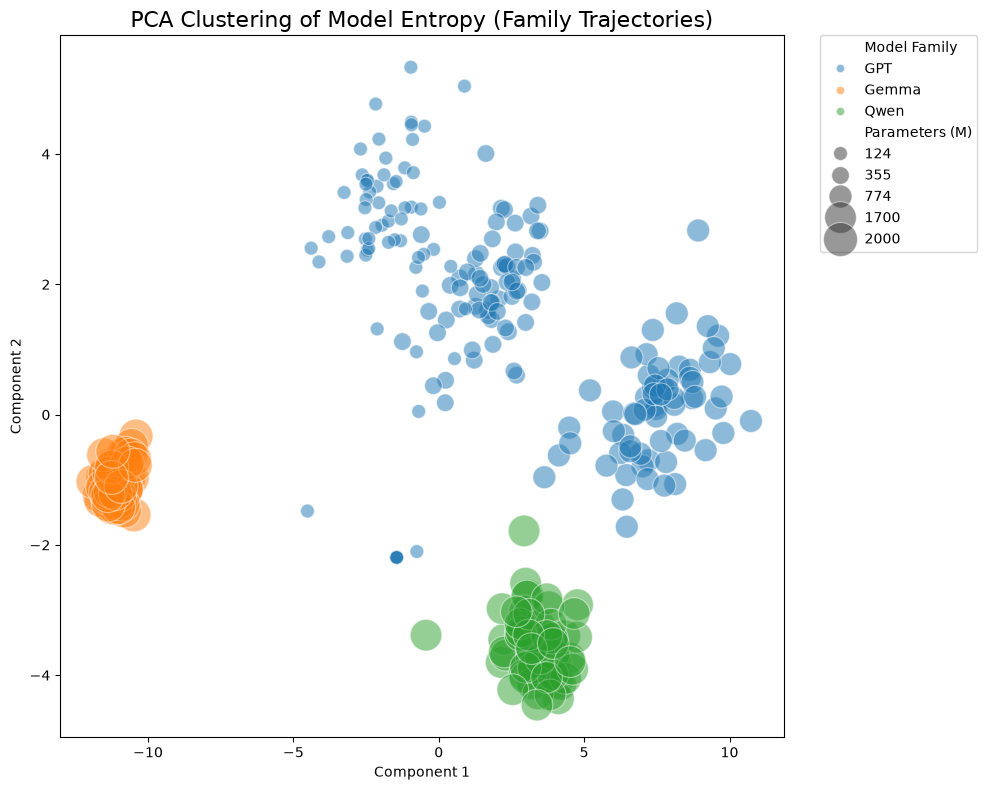

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

# ==============================================================================
# HELPER FUNCTION: Interpolation
# ==============================================================================
def interpolate_entropy_profile(layers, entropies, num_standard_features=50):
    """
    Standardizes models of different depths (e.g., 12 layers vs 36 layers) 
    by stretching/compressing their entropy curves into a fixed number of points.
    """
    if len(layers) <= 1:
        return np.zeros(num_standard_features)
        
    # Normalize the x-axis (layers) to a 0.0 -> 1.0 scale
    layer_min, layer_max = min(layers), max(layers)
    normalized_layers = [(l - layer_min) / (layer_max - layer_min) for l in layers]
    
    # Create a line of best fit and resample it at 50 even intervals
    interp_func = interp1d(normalized_layers, entropies, kind='linear', fill_value="extrapolate")
    standard_x = np.linspace(0.0, 1.0, num_standard_features)
    return interp_func(standard_x)


# ==============================================================================
# MAIN CLUSTERING SCRIPT
# ==============================================================================

# 1. USER CONFIGURATION: Model Mapping
# MODIFY THIS DICTIONARY to add your own models.
# - The KEY must exactly match the 'architecture' string in your final_df.
# - 'family': Group models by their architecture family (this determines the COLOR).
# - 'params': The parameter count in millions (this determines the DOT SIZE).
family_mapping = {
    "GPT-2 (Small)": {"family": "GPT", "params": 124},
    "GPT-2 (Medium)": {"family": "GPT", "params": 355},
    "GPT-2 (Large)": {"family": "GPT", "params": 774},
    "Gemma-2 (2B-IT)": {"family": "Gemma", "params": 2000},
    "Qwen 3 (1.7B)": {"family": "Qwen", "params": 1700}
    # Example of adding a new model:
    # "Llama-3 (8B)": {"family": "Llama", "params": 8000}
}

# Apply the mapping configuration to the dataframe
# (Assumes `final_df` is already loaded from your EntropyPipeline extraction)
final_df = pd.concat(all_results, ignore_index=True)
final_df['Family'] = final_df['architecture'].map(lambda x: family_mapping[x]['family'])
final_df['Parameters (M)'] = final_df['architecture'].map(lambda x: family_mapping[x]['params'])

print("1. Preparing data and normalizing layer depths...")
feature_vectors = []
families = []
param_sizes = []

# Group the data by specific sample iterations
grouped = final_df.groupby(['architecture', 'position'])

for (arch, pos), group_df in grouped:
    group_df = group_df.sort_values(by='layer')
    layers = group_df['layer'].values
    entropies = group_df['entropy'].values
    
    if len(layers) > 1:
        # Standardize all models to have exactly 50 dimensions (features)
        # MODIFY THIS (50) if you want higher/lower resolution in the shape of the curve
        standardized = interpolate_entropy_profile(layers, entropies, 50)
        
        feature_vectors.append(standardized)
        families.append(group_df['Family'].iloc[0])
        param_sizes.append(group_df['Parameters (M)'].iloc[0])
        
X = np.array(feature_vectors)

# 2. SCALING AND DIMENSIONALITY REDUCTION
print("2. Scaling data and running PCA...")

# StandardScaler performs Global Normalization. 
# It keeps the relative distances intact so that Large models and Small models
# of the same family form a continuous trajectory rather than separate islands.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize Principal Component Analysis (PCA)
# We reduce the 50 dimensions down to 2 dimensions for X/Y plotting.
# (If you prefer t-SNE, replace PCA with TSNE(n_components=2, perplexity=30) here)
pca = PCA(n_components=2)
X_embedded = pca.fit_transform(X_scaled)

# Create a clean DataFrame specifically formatted for Seaborn plotting
plot_df = pd.DataFrame({
    'Component 1': X_embedded[:, 0],
    'Component 2': X_embedded[:, 1],
    'Model Family': families,
    'Parameters (M)': param_sizes
})

# 3. PLOTTING CONFIGURATION
print("3. Generating plot matching the authors' style...")
plt.figure(figsize=(10, 8))

# Seaborn Scatterplot
sns.scatterplot(
    data=plot_df, 
    x='Component 1', 
    y='Component 2', 
    hue='Model Family',       # MODIFY: What column dictates the colors?
    size='Parameters (M)',    # MODIFY: What column dictates dot size?
    sizes=(100, 600),         # MODIFY: Min and Max dot sizes. Increase if overlap is too small.
    palette='tab10',          # MODIFY: Change color scheme (e.g., 'viridis', 'Set2')
    alpha=0.5,                # MODIFY: Transparency (0.0 to 1.0). 0.5 allows overlapping clusters to blend.
    edgecolor='white'
)

# Customize title and legend
plt.title("PCA Clustering of Model Entropy (Family Trajectories)", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Finalize and save
plt.tight_layout()
plt.savefig("authors_reproduction_pca.png", dpi=300)
plt.show()